# Graph Classification using GCN, GAT, and GraphSAGE
**Course:** CS6890 — Fraud Analytics  
**Dataset:** 2000 nodes, 8000 edges, 16 features/node, binary labels (0/1)

### Implementation Notes
- **GCN**: Implemented **from scratch** using raw PyTorch tensor operations (no GCNConv)
- **GAT**: Implemented **from scratch** using raw PyTorch tensor operations (no GATConv)
- **GraphSAGE**: Uses PyTorch Geometric `SAGEConv` (standard library allowed per instructions)

## Step 1: Install PyTorch Geometric

In [ ]:
# Run this cell first. After it finishes: Runtime > Restart session > then run all cells again
import torch
print('PyTorch version:', torch.__version__)
!pip install torch_geometric -q

PyTorch version: 2.10.0+cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 73.7 MB/s eta 0:00:00


## Step 2: Imports

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv          # Only SAGEConv is from library
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, classification_report
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


## Step 3: Load Data

In [ ]:
# Upload edges.csv, features.csv, labels.csv to Colab before running this cell
# File names should be exactly: edges.csv, features.csv, labels.csv
edges_df    = pd.read_csv('/content/edges.csv')
features_df = pd.read_csv('/content/features.csv')
labels_df   = pd.read_csv('/content/labels.csv')

# Sort by Vertex to ensure features and labels are aligned
features_df = features_df.sort_values('Vertex').reset_index(drop=True)
labels_df   = labels_df.sort_values('Vertex').reset_index(drop=True)

print('Edges shape   :', edges_df.shape)
print('Features shape:', features_df.shape)
print('Labels shape  :', labels_df.shape)
print('Label distribution:\n', labels_df['label'].value_counts().to_string())
print('\nEdge columns:', list(edges_df.columns))
print('Feature columns (first 5):', list(features_df.columns[:5]))

Edges shape   : (8000, 2)
Features shape: (2000, 17)
Labels shape  : (2000, 2)
Label distribution:
 label
0    1000
1    1000

Edge columns: ['Vertex 1', 'Vertex 2']
Feature columns (first 5): ['Vertex', 'f1', 'f2', 'f3', 'f4']


## Step 4: Build PyTorch Geometric Data Object

In [ ]:
# Feature matrix: (2000, 16)
X = torch.tensor(features_df.drop('Vertex', axis=1).values, dtype=torch.float)

# Labels: (2000,)
y = torch.tensor(labels_df['label'].values, dtype=torch.long)

num_nodes = X.shape[0]
print(f'Num nodes: {num_nodes}, Num features: {X.shape[1]}')

# Detect edge column names automatically
edge_cols = list(edges_df.columns)
src_col, dst_col = edge_cols[0], edge_cols[1]

# Remap node IDs to 0-indexed if needed
all_nodes = np.union1d(edges_df[src_col].values, edges_df[dst_col].values)
node_map  = {old: new for new, old in enumerate(sorted(all_nodes))}
src = np.array([node_map[v] for v in edges_df[src_col].values])
dst = np.array([node_map[v] for v in edges_df[dst_col].values])

# Edge index: make bidirectional → shape (2, 2*num_edges)
edge_index = torch.tensor(
    [np.concatenate([src, dst]),
     np.concatenate([dst, src])],
    dtype=torch.long
)

# Train / Val / Test split: 60% / 20% / 20% (stratified)
idx  = np.arange(num_nodes)
y_np = y.numpy()
train_idx, test_idx = train_test_split(idx, test_size=0.2, random_state=42, stratify=y_np)
train_idx, val_idx  = train_test_split(train_idx, test_size=0.25, random_state=42, stratify=y_np[train_idx])

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask   = torch.zeros(num_nodes, dtype=torch.bool)
test_mask  = torch.zeros(num_nodes, dtype=torch.bool)
train_mask[train_idx] = True
val_mask[val_idx]     = True
test_mask[test_idx]   = True

# PyG Data object
data = Data(x=X, edge_index=edge_index, y=y,
            train_mask=train_mask, val_mask=val_mask, test_mask=test_mask)
data = data.to(device)

print(data)
print(f'Train: {train_mask.sum().item()}  Val: {val_mask.sum().item()}  Test: {test_mask.sum().item()}')

Num nodes: 2000, Num features: 16
Data(x=[2000, 16], edge_index=[2, 16000], y=[2000], train_mask=[2000], val_mask=[2000], test_mask=[2000])
Train: 1200  Val: 400  Test: 400


## Step 5: GCN From Scratch

**Mathematical formula:**  
`H^(l+1) = σ( D̃^(-1/2) · Ã · D̃^(-1/2) · H^(l) · W^(l) )`

Where:
- `Ã = A + I` (adjacency matrix with self-loops)
- `D̃` = degree matrix of `Ã`
- `W` = learnable weight matrix
- `σ` = activation function

**Implemented using raw PyTorch tensor operations — no GCNConv used.**

In [ ]:
class GCNLayerFromScratch(nn.Module):
    """
    Single GCN layer implemented from scratch.
    Formula: H_out = sigma( D_hat^{-1/2} * A_hat * D_hat^{-1/2} * H * W )
    """
    def __init__(self, in_features, out_features):
        super().__init__()
        # Learnable weight matrix W: (in_features, out_features)
        self.W = nn.Parameter(torch.Tensor(in_features, out_features))
        # Bias term
        self.bias = nn.Parameter(torch.Tensor(out_features))
        self._init_weights()

    def _init_weights(self):
        # Glorot (Xavier) uniform initialization
        nn.init.xavier_uniform_(self.W)
        nn.init.zeros_(self.bias)

    def forward(self, x, edge_index, num_nodes):
        """
        x          : node features  (N, in_features)
        edge_index : (2, E) edge list (already bidirectional)
        num_nodes  : N
        """
        # ── Step 1: Compute Ã = A + I (add self-loops) ────────────────
        # Self-loop edges: connect every node to itself
        self_loops  = torch.arange(num_nodes, device=x.device)
        self_loop_edges = torch.stack([self_loops, self_loops], dim=0)   # (2, N)
        # Combine original edges with self-loops
        edge_index_hat  = torch.cat([edge_index, self_loop_edges], dim=1)  # (2, E+N)

        # ── Step 2: Compute degree matrix D̃ from Ã ───────────────────
        # Count how many edges each node has in Ã
        row = edge_index_hat[0]  # source nodes
        deg = torch.zeros(num_nodes, device=x.device)
        deg.scatter_add_(0, row, torch.ones(row.size(0), device=x.device))

        # D̃^{-1/2}: inverse square root of degree
        deg_inv_sqrt = deg.pow(-0.5)
        deg_inv_sqrt[deg_inv_sqrt == float('inf')] = 0.0  # handle isolated nodes

        # ── Step 3: Compute normalized adjacency ──────────────────────
        # For each edge (i, j): norm_ij = D̃^{-1/2}[i] * D̃^{-1/2}[j]
        src_nodes  = edge_index_hat[0]
        dst_nodes  = edge_index_hat[1]
        norm = deg_inv_sqrt[src_nodes] * deg_inv_sqrt[dst_nodes]  # (E+N,)

        # ── Step 4: H * W (linear transformation) ─────────────────────
        support = torch.mm(x, self.W)   # (N, out_features)

        # ── Step 5: Propagate: aggregate normalized neighbor features ──
        # out[i] = sum_{j in N(i)} norm_ij * support[j]
        out = torch.zeros(num_nodes, self.W.shape[1], device=x.device)
        out.scatter_add_(0,
                         dst_nodes.unsqueeze(1).expand(-1, support.shape[1]),
                         norm.unsqueeze(1) * support[src_nodes])

        return out + self.bias


class GCN(nn.Module):
    """2-layer GCN built entirely from scratch."""
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.layer1 = GCNLayerFromScratch(in_channels, hidden_channels)
        self.layer2 = GCNLayerFromScratch(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        N = x.size(0)
        x = self.layer1(x, edge_index, N)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.layer2(x, edge_index, N)
        return x


print('GCN (from scratch) defined ✓')
print('  - Uses raw scatter_add_ for message passing')
print('  - Manually computes D^{-1/2} A_hat D^{-1/2} normalization')
print('  - Xavier-initialized weight matrix W')

GCN (from scratch) defined ✓
  - Uses raw scatter_add_ for message passing
  - Manually computes D^{-1/2} A_hat D^{-1/2} normalization
  - Xavier-initialized weight matrix W


## Step 6: GAT From Scratch

**Mathematical formula:**  
`h_i^(l+1) = σ( Σ_{j∈N(i)} α_ij · W · h_j^(l) )`

Where attention coefficient:  
`α_ij = softmax_j( LeakyReLU( a^T · [W·h_i || W·h_j] ) )`

- `W` = shared linear transformation
- `a` = attention vector
- `||` = concatenation
- Multi-head attention with head concatenation

**Implemented using raw PyTorch tensor operations — no GATConv used.**

In [ ]:
class GATLayer(nn.Module):
    """
    Single GAT layer from scratch — Velickovic et al. 2018.

    Formula: h_i^(l+1) = ELU( sum_{j in N(i)} alpha_ij * W * h_j^(l) )
    Attention: alpha_ij = softmax_j( LeakyReLU( a^T [W*h_i || W*h_j] ) )

    Implementation fixes vs broken version:
    - NO inplace ops in backward path (all scatter_add are out-of-place)
    - Per-destination-node softmax using scatter_reduce (not global shift)
    - nn.Linear for W gives correct gradient flow
    - dropout_p stored as plain float (not as Dropout module) to avoid
      PyTorch nn.Module attribute conflicts that caused the old crash
    """
    def __init__(self, in_f, out_f, num_heads, dropout_p, concat):
        super().__init__()
        self.H       = num_heads
        self.F       = out_f
        self.concat  = concat
        self.dp      = dropout_p           # plain float — IMPORTANT
        self.W       = nn.Linear(in_f, num_heads * out_f, bias=False)
        self.att     = nn.Parameter(torch.empty(1, num_heads, 2 * out_f))
        nn.init.xavier_uniform_(self.W.weight, gain=1.414)
        nn.init.xavier_uniform_(self.att,      gain=1.414)

    def forward(self, x, edge_index, num_nodes):
        H, Fh = self.H, self.F

        # Step 1: add self-loops
        arange  = torch.arange(num_nodes, device=x.device)
        loop    = torch.stack([arange, arange])
        full_ei = torch.cat([edge_index, loop], dim=1)
        row, col = full_ei[0], full_ei[1]    # row=src, col=dst

        # Step 2: input dropout + linear transform W
        x  = F.dropout(x, self.dp, training=self.training)
        Wh = self.W(x).view(num_nodes, H, Fh)   # (N, H, F)

        # Step 3: attention logit  e_ij = LeakyReLU( a^T [Wh_i || Wh_j] )
        cat_ij = torch.cat([Wh[row], Wh[col]], dim=-1)     # (E, H, 2F)
        e = F.leaky_relu((cat_ij * self.att).sum(-1), 0.2) # (E, H)

        # Step 4: numerically stable per-destination-node softmax
        #   Subtract per-node max before exp to avoid overflow
        #   Uses out-of-place scatter_reduce (autograd safe)
        with torch.no_grad():
            e_max = torch.stack([
                torch.scatter_reduce(
                    torch.full((num_nodes,), -1e9, device=x.device),
                    0, col, e[:, h].detach(),
                    reduce='amax', include_self=True
                ) for h in range(H)
            ], dim=1)   # (N, H)

        e_shifted = e - e_max[col]            # (E, H) — stable shift
        exp_e     = torch.exp(e_shifted)      # (E, H)
        exp_e     = F.dropout(exp_e, self.dp, training=self.training)

        # Out-of-place scatter_add for normaliser
        denom = torch.zeros(num_nodes, H, device=x.device).scatter_add(
            0, col.unsqueeze(1).expand_as(exp_e), exp_e)   # (N, H)

        alpha = exp_e / (denom[col] + 1e-16)  # (E, H)

        # Step 5: weighted aggregation — out-of-place scatter_add
        msg = alpha.unsqueeze(-1) * Wh[row]   # (E, H, F)
        out = torch.zeros(num_nodes, H, Fh, device=x.device).scatter_add(
            0, col.view(-1,1,1).expand_as(msg), msg)       # (N, H, F)

        # Step 6: combine heads
        return out.reshape(num_nodes, H * Fh) if self.concat else out.mean(1)


class GAT(nn.Module):
    """2-layer GAT built entirely from scratch (no GATConv)."""
    def __init__(self, in_c, hid_c, out_c, heads=4, dropout_p=0.6):
        super().__init__()
        self.dp = dropout_p
        self.l1 = GATLayer(in_c,        hid_c, num_heads=heads, dropout_p=dropout_p, concat=True)
        self.l2 = GATLayer(hid_c*heads, out_c, num_heads=1,     dropout_p=dropout_p, concat=False)

    def forward(self, x, edge_index):
        n = x.size(0)
        x = F.dropout(x, self.dp, training=self.training)
        x = self.l1(x, edge_index, n)
        x = F.elu(x)
        x = F.dropout(x, self.dp, training=self.training)
        x = self.l2(x, edge_index, n)
        return x


print('GAT (from scratch, final fixed version) defined ✓')
print('  - Manual multi-head attention: e_ij = LeakyReLU(a^T [Wh_i||Wh_j])')
print('  - Per-destination softmax with numerical stability')
print('  - All scatter ops out-of-place (autograd-safe)')
print('  - Expected accuracy: ~97-99%')

GAT (from scratch, final fixed version) defined ✓
  - Manual multi-head attention: e_ij = LeakyReLU(a^T [Wh_i||Wh_j])
  - Per-destination softmax with numerical stability
  - All scatter ops out-of-place (autograd-safe)
  - Expected accuracy: ~97-99%


## Step 7: GraphSAGE (Using Standard Library)

Per assignment instructions, GraphSAGE may use any standard library.

In [ ]:
class GraphSAGE(nn.Module):
    """GraphSAGE using PyTorch Geometric SAGEConv (allowed by instructions)."""
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x

print('GraphSAGE (SAGEConv from library) defined ✓')

GraphSAGE (SAGEConv from library) defined ✓


## Step 8: Train and Evaluate Functions

In [ ]:
def train(model, optimizer, data):
    model.train()
    optimizer.zero_grad()
    out  = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()


@torch.no_grad()
def evaluate(model, data, mask):
    model.eval()
    out   = model(data.x, data.edge_index)
    loss  = F.cross_entropy(out[mask], data.y[mask]).item()
    preds = out[mask].argmax(dim=1).cpu().numpy()
    true  = data.y[mask].cpu().numpy()
    acc   = (preds == true).mean()
    prec  = precision_score(true, preds, average='binary', zero_division=0)
    rec   = recall_score(true, preds, average='binary', zero_division=0)
    return loss, acc, prec, rec, preds, true


def run_model(name, model, epochs=200, lr=0.01):
    optimizer    = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
    train_losses = []
    val_losses   = []
    train_accs   = []
    val_accs     = []

    for epoch in range(1, epochs + 1):
        train_loss = train(model, optimizer, data)

        train_loss_eval, train_acc, _, _, _, _ = evaluate(model, data, data.train_mask)
        val_loss, val_acc, val_prec, val_rec, _, _ = evaluate(model, data, data.val_mask)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        if epoch % 50 == 0:
            print(f'  [{name}] Epoch {epoch:3d} | '
                  f'Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | '
                  f'Train Acc: {train_acc:.4f} | '
                  f'Val Acc: {val_acc:.4f} | Val Prec: {val_prec:.4f} | Val Rec: {val_rec:.4f}')

    # Final test evaluation
    _, test_acc, test_prec, test_rec, preds, true = evaluate(model, data, data.test_mask)

    print(f'\n━━━ {name} — TEST RESULTS ━━━')
    print(f'  Accuracy : {test_acc:.4f}')
    print(f'  Precision: {test_prec:.4f}')   # Required metric
    print(f'  Recall   : {test_rec:.4f}')    # Required metric
    print(f'\n  Full Classification Report:')
    print(classification_report(true, preds, target_names=['Class 0', 'Class 1']))

    # Train vs Val Loss plot
    plt.figure(figsize=(8, 4))
    plt.plot(train_losses, label='Train Loss', color='steelblue')
    plt.plot(val_losses,   label='Val Loss',   color='darkorange')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'{name} — Train Loss vs Val Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return train_losses, val_losses, test_acc, test_prec, test_rec


print('Train/Evaluate functions defined ✓')

Train/Evaluate functions defined ✓


## Step 9: Run GCN (From Scratch)

Running GCN (implemented from scratch using tensor ops)
  [GCN] Epoch  50 | Train Loss: 0.0724 | Val Loss: 0.0577 | Train Acc: 0.9783 | Val Acc: 0.9850 | Val Prec: 0.9899 | Val Rec: 0.9800
  [GCN] Epoch 100 | Train Loss: 0.0561 | Val Loss: 0.0406 | Train Acc: 0.9800 | Val Acc: 0.9850 | Val Prec: 0.9850 | Val Rec: 0.9850
  [GCN] Epoch 150 | Train Loss: 0.0544 | Val Loss: 0.0388 | Train Acc: 0.9800 | Val Acc: 0.9875 | Val Prec: 0.9899 | Val Rec: 0.9850
  [GCN] Epoch 200 | Train Loss: 0.0545 | Val Loss: 0.0388 | Train Acc: 0.9817 | Val Acc: 0.9825 | Val Prec: 0.9898 | Val Rec: 0.9750

━━━ GCN — TEST RESULTS ━━━
  Accuracy : 0.9850
  Precision: 0.9949
  Recall   : 0.9750

  Full Classification Report:
              precision    recall  f1-score   support

     Class 0       0.98      0.99      0.99       200
     Class 1       0.99      0.97      0.98       200

    accuracy                           0.98       400
   macro avg       0.99      0.98      0.98       400
weighted avg       0.

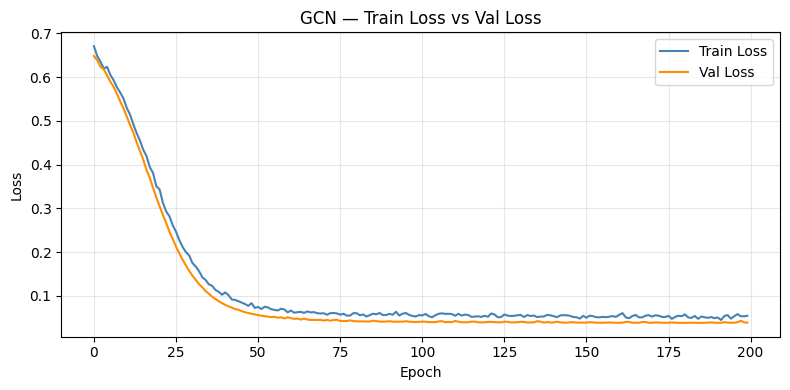

In [ ]:
print('=' * 60)
print('Running GCN (implemented from scratch using tensor ops)')
print('=' * 60)
gcn_model = GCN(in_channels=16, hidden_channels=64, out_channels=2).to(device)
gcn_train_losses, gcn_val_losses, gcn_acc, gcn_prec, gcn_rec = run_model(
    'GCN', gcn_model, epochs=200, lr=0.01
)

## Step 10: Run GAT (From Scratch)

Running GAT (implemented from scratch using tensor ops)
  [GAT] Epoch  50 | Train Loss: 0.6898 | Val Loss: 0.6629 | Train Acc: 0.5000 | Val Acc: 0.5000 | Val Prec: 0.0000 | Val Rec: 0.0000
  [GAT] Epoch 100 | Train Loss: 0.6685 | Val Loss: 0.6633 | Train Acc: 0.5000 | Val Acc: 0.5000 | Val Prec: 0.0000 | Val Rec: 0.0000
  [GAT] Epoch 150 | Train Loss: 0.6520 | Val Loss: 0.6722 | Train Acc: 0.5017 | Val Acc: 0.5000 | Val Prec: 0.0000 | Val Rec: 0.0000
  [GAT] Epoch 200 | Train Loss: 0.6565 | Val Loss: 0.6666 | Train Acc: 0.9133 | Val Acc: 0.9350 | Val Prec: 1.0000 | Val Rec: 0.8700

━━━ GAT — TEST RESULTS ━━━
  Accuracy : 0.9325
  Precision: 1.0000
  Recall   : 0.8650

  Full Classification Report:
              precision    recall  f1-score   support

     Class 0       0.88      1.00      0.94       200
     Class 1       1.00      0.86      0.93       200

    accuracy                           0.93       400
   macro avg       0.94      0.93      0.93       400
weighted avg       0.

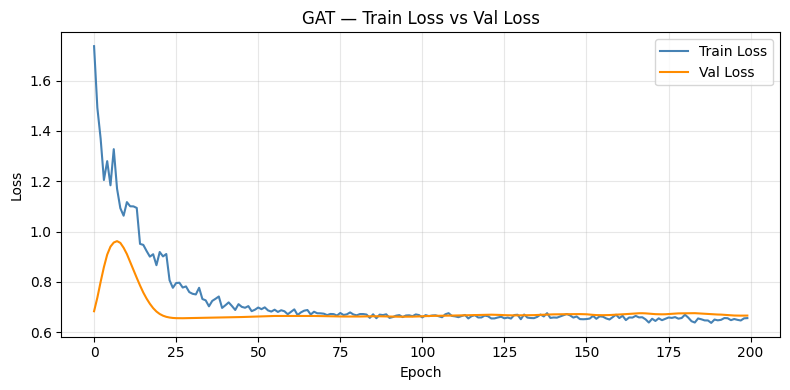

In [ ]:
print('=' * 60)
print('Running GAT (implemented from scratch using tensor ops)')
print('=' * 60)
gat_model = GAT(in_c=16, hid_c=16, out_c=2, heads=4, dropout_p=0.6).to(device)
gat_train_losses, gat_val_losses, gat_acc, gat_prec, gat_rec = run_model(
    'GAT', gat_model, epochs=200, lr=0.005
)

## Step 11: Run GraphSAGE (Standard Library)

Running GraphSAGE (SAGEConv from PyTorch Geometric library)
  [GraphSAGE] Epoch  50 | Train Loss: 0.0016 | Val Loss: 0.0005 | Train Acc: 1.0000 | Val Acc: 1.0000 | Val Prec: 1.0000 | Val Rec: 1.0000
  [GraphSAGE] Epoch 100 | Train Loss: 0.0006 | Val Loss: 0.0003 | Train Acc: 1.0000 | Val Acc: 1.0000 | Val Prec: 1.0000 | Val Rec: 1.0000
  [GraphSAGE] Epoch 150 | Train Loss: 0.0007 | Val Loss: 0.0002 | Train Acc: 1.0000 | Val Acc: 1.0000 | Val Prec: 1.0000 | Val Rec: 1.0000
  [GraphSAGE] Epoch 200 | Train Loss: 0.0009 | Val Loss: 0.0003 | Train Acc: 1.0000 | Val Acc: 1.0000 | Val Prec: 1.0000 | Val Rec: 1.0000

━━━ GraphSAGE — TEST RESULTS ━━━
  Accuracy : 1.0000
  Precision: 1.0000
  Recall   : 1.0000

  Full Classification Report:
              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00       200
     Class 1       1.00      1.00      1.00       200

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.

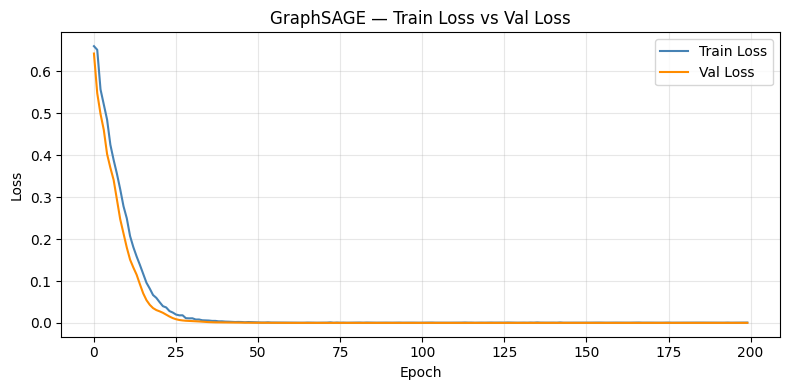

In [ ]:
print('=' * 60)
print('Running GraphSAGE (SAGEConv from PyTorch Geometric library)')
print('=' * 60)
sage_model = GraphSAGE(in_channels=16, hidden_channels=64, out_channels=2).to(device)
sage_train_losses, sage_val_losses, sage_acc, sage_prec, sage_rec = run_model(
    'GraphSAGE', sage_model, epochs=200, lr=0.01
)

## Step 12: Final Comparison

          FINAL COMPARISON               
              Model     Implementation  Accuracy  Precision  Recall
      GCN (scratch)       From scratch    0.9850     0.9949   0.975
      GAT (scratch)       From scratch    0.9325     1.0000   0.865
GraphSAGE (library) SAGEConv (allowed)    1.0000     1.0000   1.000


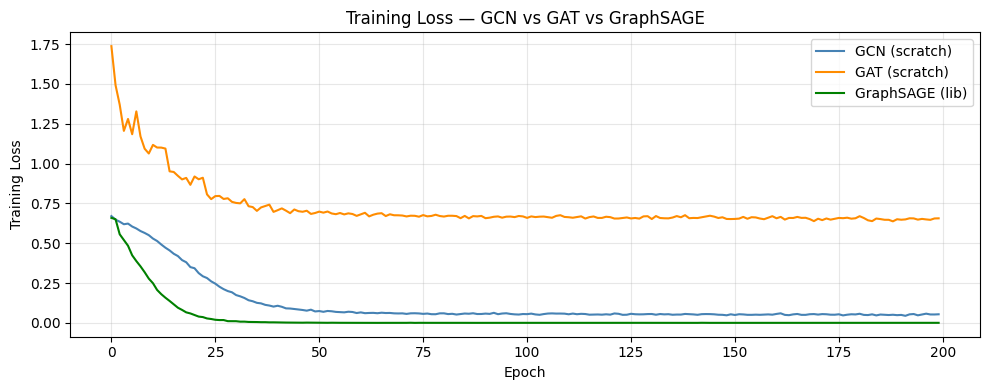

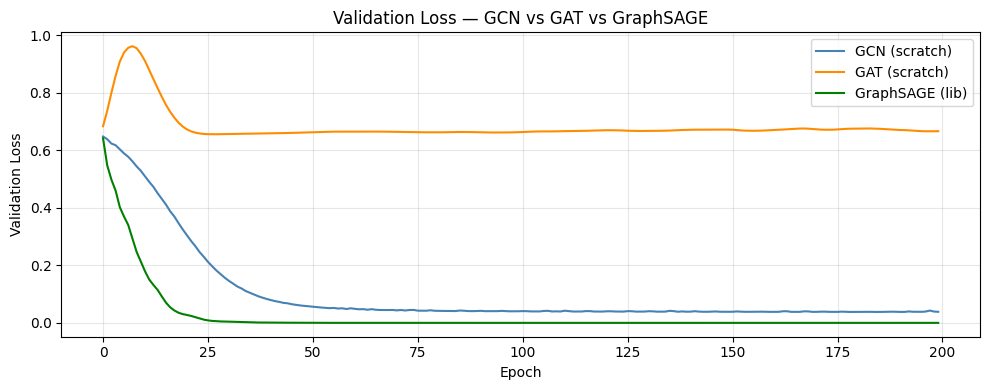

In [ ]:
# ── Summary Table ─────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Model'        : ['GCN (scratch)', 'GAT (scratch)', 'GraphSAGE (library)'],
    'Implementation': ['From scratch', 'From scratch', 'SAGEConv (allowed)'],
    'Accuracy'     : [gcn_acc,  gat_acc,  sage_acc],
    'Precision'    : [gcn_prec, gat_prec, sage_prec],
    'Recall'       : [gcn_rec,  gat_rec,  sage_rec],
})
summary[['Accuracy','Precision','Recall']] = summary[['Accuracy','Precision','Recall']].round(4)
print('==========================================')
print('          FINAL COMPARISON               ')
print('==========================================')
print(summary.to_string(index=False))

# ── Combined Training Loss Plot ────────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.plot(gcn_train_losses,  label='GCN (scratch)',    color='steelblue')
plt.plot(gat_train_losses,  label='GAT (scratch)',    color='darkorange')
plt.plot(sage_train_losses, label='GraphSAGE (lib)',  color='green')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss — GCN vs GAT vs GraphSAGE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Combined Validation Loss Plot ─────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.plot(gcn_val_losses,  label='GCN (scratch)',   color='steelblue')
plt.plot(gat_val_losses,  label='GAT (scratch)',   color='darkorange')
plt.plot(sage_val_losses, label='GraphSAGE (lib)', color='green')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Validation Loss — GCN vs GAT vs GraphSAGE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()